# Lab 08: Text Classification with SimpleRNN (IMDb)

## Student
- Name: Ali Hamza
- Roll Number: B23F0063AI106
- Section: B.S AI - Red

## What you must do
Run all cells in order in Google Colab.
At the end, the notebook will generate:
- `Lab_Report_8.md`
- `Lab_Report_8.html`
and save plots into `BASE_DIR/plots/`.


In [2]:
import os
from datetime import datetime

# -----------------------------
# Student metadata (edit only if needed)
# -----------------------------
STUDENT_NAME = "Ali Hamza"
STUDENT_ROLL = "B23F0063AI106"
STUDENT_SECTION = "B.S AI - Red"
STUDENT_FOLDER_NAME = "Ali Hamza's Lab"

# -----------------------------
# Colab / local path handling
# -----------------------------
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_DIR = f"/content/drive/MyDrive/COMP-341L/Lab 8/{STUDENT_FOLDER_NAME}"
else:
    BASE_DIR = os.environ.get("LAB8_BASE_DIR", ".")

BASE_DIR = os.environ.get('LAB8_BASE_DIR', BASE_DIR)
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print('BASE_DIR:', os.path.abspath(BASE_DIR))
print('PLOTS_DIR:', os.path.abspath(PLOTS_DIR))


Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab
PLOTS_DIR: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots


## Task 1: Dataset (IMDb Sentiment Analysis)
We will use the publicly available IMDb dataset from `tf.keras.datasets.imdb`.

- **Input format:** tokenized movie-review sequences (integer word IDs)
- **Output format:** sentiment label `0/1` (negative/positive)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Raw shapes:
x_train: 25000 y_train: (25000,)
x_test : 25000 y_test : (25000,)
Padded shapes:
x_train: (25000, 200) x_test: (25000, 200)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_6627/3762935492.py:69: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6627/3762935492.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_6627/3762935492.py:70: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(task1_path, dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


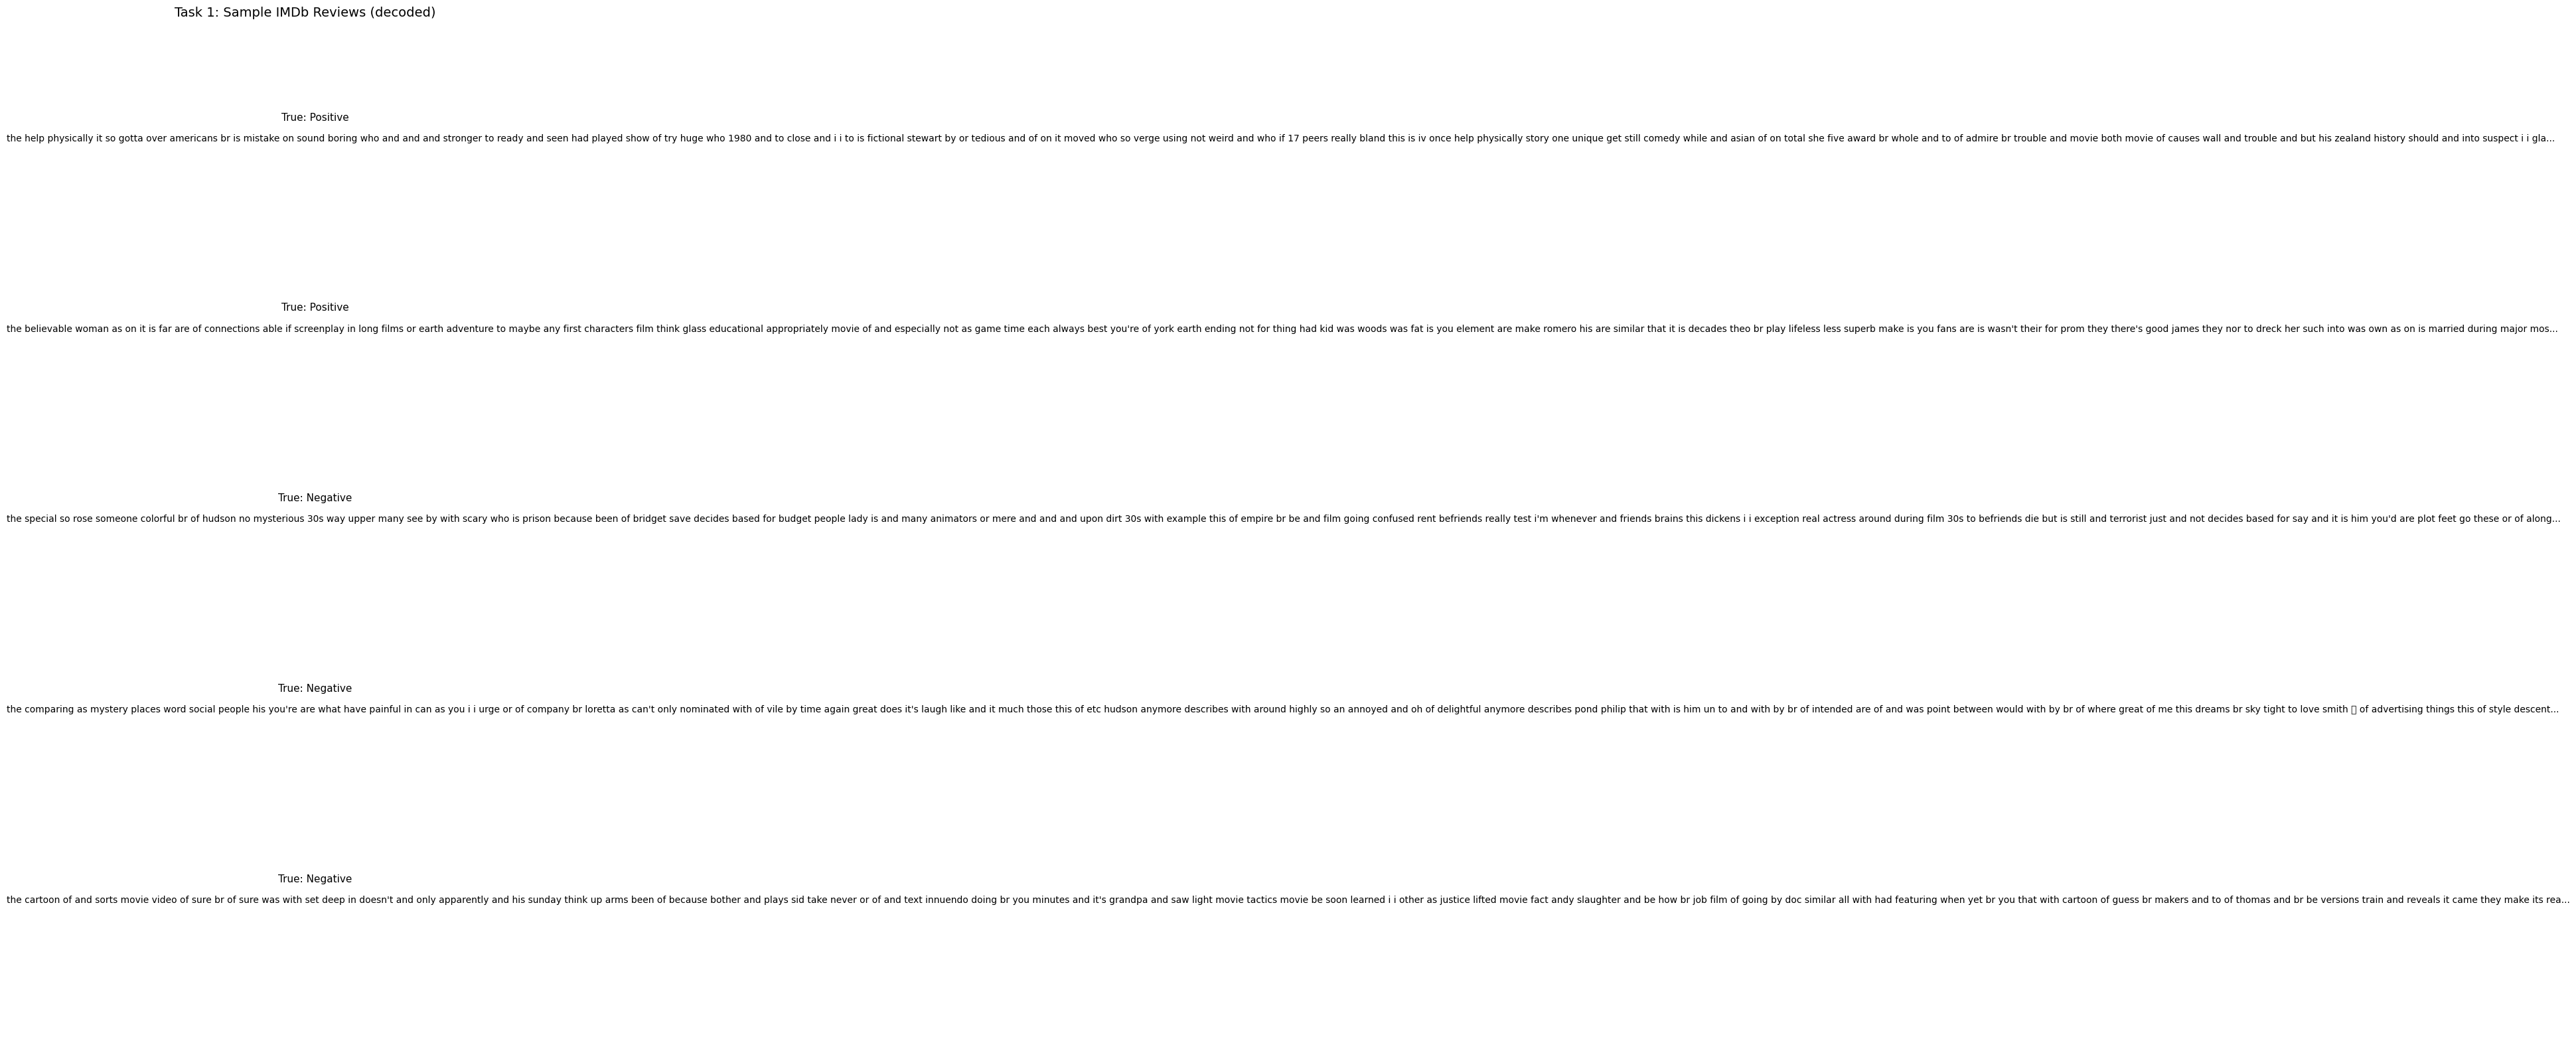

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task1_sample_reviews.png


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Keep sizes reasonable for Colab runtime
MAX_FEATURES = 10000
MAX_LEN = 200
EMBEDDING_DIM = 64
RNN_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 10

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.imdb.load_data(
    num_words=MAX_FEATURES
)

print('Raw shapes:')
print('x_train:', len(x_train_raw), 'y_train:', y_train_raw.shape)
print('x_test :', len(x_test_raw), 'y_test :', y_test_raw.shape)

# imdb labels are 0/1 already
y_train = y_train_raw.astype('float32')
y_test = y_test_raw.astype('float32')

# Padding/truncation (post-padding)
x_train = tf.keras.preprocessing.sequence.pad_sequences(
    x_train_raw, maxlen=MAX_LEN, padding='post', truncating='post'
)
x_test = tf.keras.preprocessing.sequence.pad_sequences(
    x_test_raw, maxlen=MAX_LEN, padding='post', truncating='post'
)

print('Padded shapes:')
print('x_train:', x_train.shape, 'x_test:', x_test.shape)

# Simple visualization of a few decoded reviews
word_index = tf.keras.datasets.imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_sequence(seq, max_words=200):
    # seq is already padded; ignore 0-padding
    words = []
    for token in seq:
        if token == 0:
            continue
        if token in reverse_word_index:
            words.append(reverse_word_index[token])
        if len(words) >= max_words:
            break
    return ' '.join(words)

seed_base = int(''.join([c for c in STUDENT_ROLL if c.isdigit()]))
np.random.seed(seed_base % 10000)
sample_indices = np.random.choice(len(x_test), size=5, replace=False)

sample_texts = []
for idx in sample_indices:
    decoded = decode_sequence(x_test[idx], max_words=120)
    true_label = 'Positive' if y_test[idx] == 1.0 else 'Negative'
    sample_texts.append((decoded, true_label))

fig, axes = plt.subplots(5, 1, figsize=(12, 18))
for ax, (text, label) in zip(axes, sample_texts):
    ax.axis('off')
    ax.set_title(f'True: {label}', fontsize=11)
    ax.text(0, 0.95, text[:550] + ('...' if len(text) > 550 else ''), fontsize=10, va='top')
plt.suptitle('Task 1: Sample IMDb Reviews (decoded)', fontsize=14)
task1_path = os.path.join(PLOTS_DIR, 'task1_sample_reviews.png')
plt.tight_layout()
plt.savefig(task1_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', task1_path)


## Task 2: Preprocessing
We use the built-in IMDb tokenization from `tf.keras.datasets.imdb` and apply padding so all sequences have the same length.

- Tokenization: integer word IDs via `imdb.load_data(num_words=...)`
- Padding/Truncation: `padding='post'` and `truncating='post'`
- Encoding: labels remain `0/1` for binary classification


In [4]:
# Preprocessing is already completed in Task 1.
print('Final preprocessing check:')
print('x_train dtype:', x_train.dtype, 'y_train dtype:', y_train.dtype)
print('x_train min/max token id:', int(x_train.min()), int(x_train.max()))


Final preprocessing check:
x_train dtype: int32 y_train dtype: float32
x_train min/max token id: 0 9999


## Task 3: Model Development (SimpleRNN)
We build an RNN for text classification using:
- `Embedding` layer
- `SimpleRNN` layer
- `Dense(sigmoid)` output for binary sentiment


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_FEATURES, EMBEDDING_DIM, input_length=MAX_LEN),
    tf.keras.layers.SimpleRNN(RNN_UNITS),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training
We train on IMDb training set and use validation split for loss/accuracy curves.

- Training: `x_train` (with validation_split inside `fit`)
- Testing: `x_test` (held out for final evaluation)


In [6]:
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1
)

final_train_acc = float(history.history['accuracy'][-1])
final_val_acc = float(history.history['val_accuracy'][-1])
final_train_loss = float(history.history['loss'][-1])
final_val_loss = float(history.history['val_loss'][-1])

print('Final training/validation:')
print('train_acc:', final_train_acc)
print('val_acc  :', final_val_acc)
print('train_loss:', final_train_loss)
print('val_loss  :', final_val_loss)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.5003 - loss: 0.6954 - val_accuracy: 0.5008 - val_loss: 0.6945
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.6032 - loss: 0.6496 - val_accuracy: 0.4998 - val_loss: 0.7235
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6946 - loss: 0.4965 - val_accuracy: 0.4932 - val_loss: 0.8456
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.7427 - loss: 0.3976 - val_accuracy: 0.4892 - val_loss: 0.9418
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7555 - loss: 0.3650 - val_accuracy: 0.4970 - val_loss: 1.0220
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7638 - loss: 0.3598 - val_accuracy: 0.4954 - val_loss: 1.1735
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.7747 - loss: 0.3459 - val_accuracy: 0.5022 - val_loss: 1.1067
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.7798 - loss: 0.3411 - 

## Task 5: Evaluation (Test Set)
We evaluate on the IMDb test set and create a confusion matrix plot.


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5069 - loss: 1.2013
Test accuracy: 0.5069199800491333
Test loss: 1.2012876272201538
Confusion matrix [[TN, FP],[FN, TP]]: [[4454, 8046], [4281, 8219]]
Sentiment labels: 0=Negative, 1=Positive

Negative: precision=0.5099, recall=0.3563, f1=0.4195
Positive: precision=0.5053, recall=0.6575, f1=0.5715

Confusion Matrix [[TN, FP],[FN, TP]]: [[4454, 8046], [4281, 8219]]

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task5_classification_report.txt


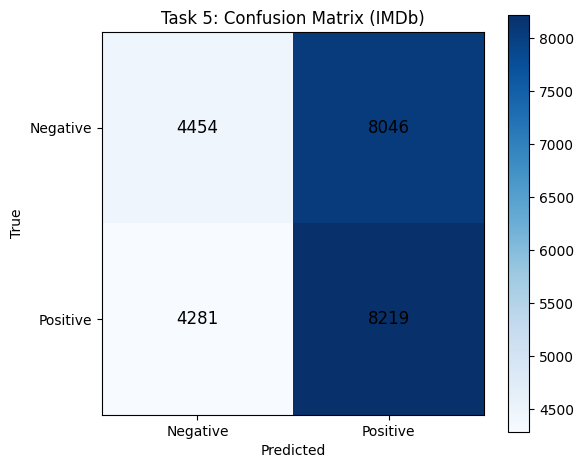

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task5_confusion_matrix.png


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print('Test accuracy:', test_acc)
print('Test loss:', test_loss)

probs = model.predict(x_test, verbose=0).reshape(-1)
y_pred = (probs >= 0.5).astype(np.float32)

# Confusion matrix for binary labels: 0=Negative, 1=Positive
tn = int(np.sum((y_test == 0) & (y_pred == 0)))
fp = int(np.sum((y_test == 0) & (y_pred == 1)))
fn = int(np.sum((y_test == 1) & (y_pred == 0)))
tp = int(np.sum((y_test == 1) & (y_pred == 1)))

cm = np.array([[tn, fp], [fn, tp]], dtype=np.int64)
print('Confusion matrix [[TN, FP],[FN, TP]]:', cm.tolist())

precision_pos = tp / max(tp + fp, 1)
recall_pos = tp / max(tp + fn, 1)
f1_pos = 2 * precision_pos * recall_pos / max(precision_pos + recall_pos, 1e-12)

precision_neg = tn / max(tn + fn, 1)
recall_neg = tn / max(tn + fp, 1)
f1_neg = 2 * precision_neg * recall_neg / max(precision_neg + recall_neg, 1e-12)

classification_report_text = (
    "Sentiment labels: 0=Negative, 1=Positive\n\n"
    f"Negative: precision={precision_neg:.4f}, recall={recall_neg:.4f}, f1={f1_neg:.4f}\n"
    f"Positive: precision={precision_pos:.4f}, recall={recall_pos:.4f}, f1={f1_pos:.4f}\n\n"
    f"Confusion Matrix [[TN, FP],[FN, TP]]: {cm.tolist()}\n"
)
print(classification_report_text)

report_path = os.path.join(PLOTS_DIR, 'task5_classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(classification_report_text + '\n')
print('Saved:', report_path)

# Plot confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)
plt.title('Task 5: Confusion Matrix (IMDb)')
task5_cm_path = os.path.join(PLOTS_DIR, 'task5_confusion_matrix.png')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(task5_cm_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', task5_cm_path)


## Task 6: Sample Predictions
We show a few test reviews with true vs predicted sentiment.


/tmp/ipykernel_6627/815902862.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


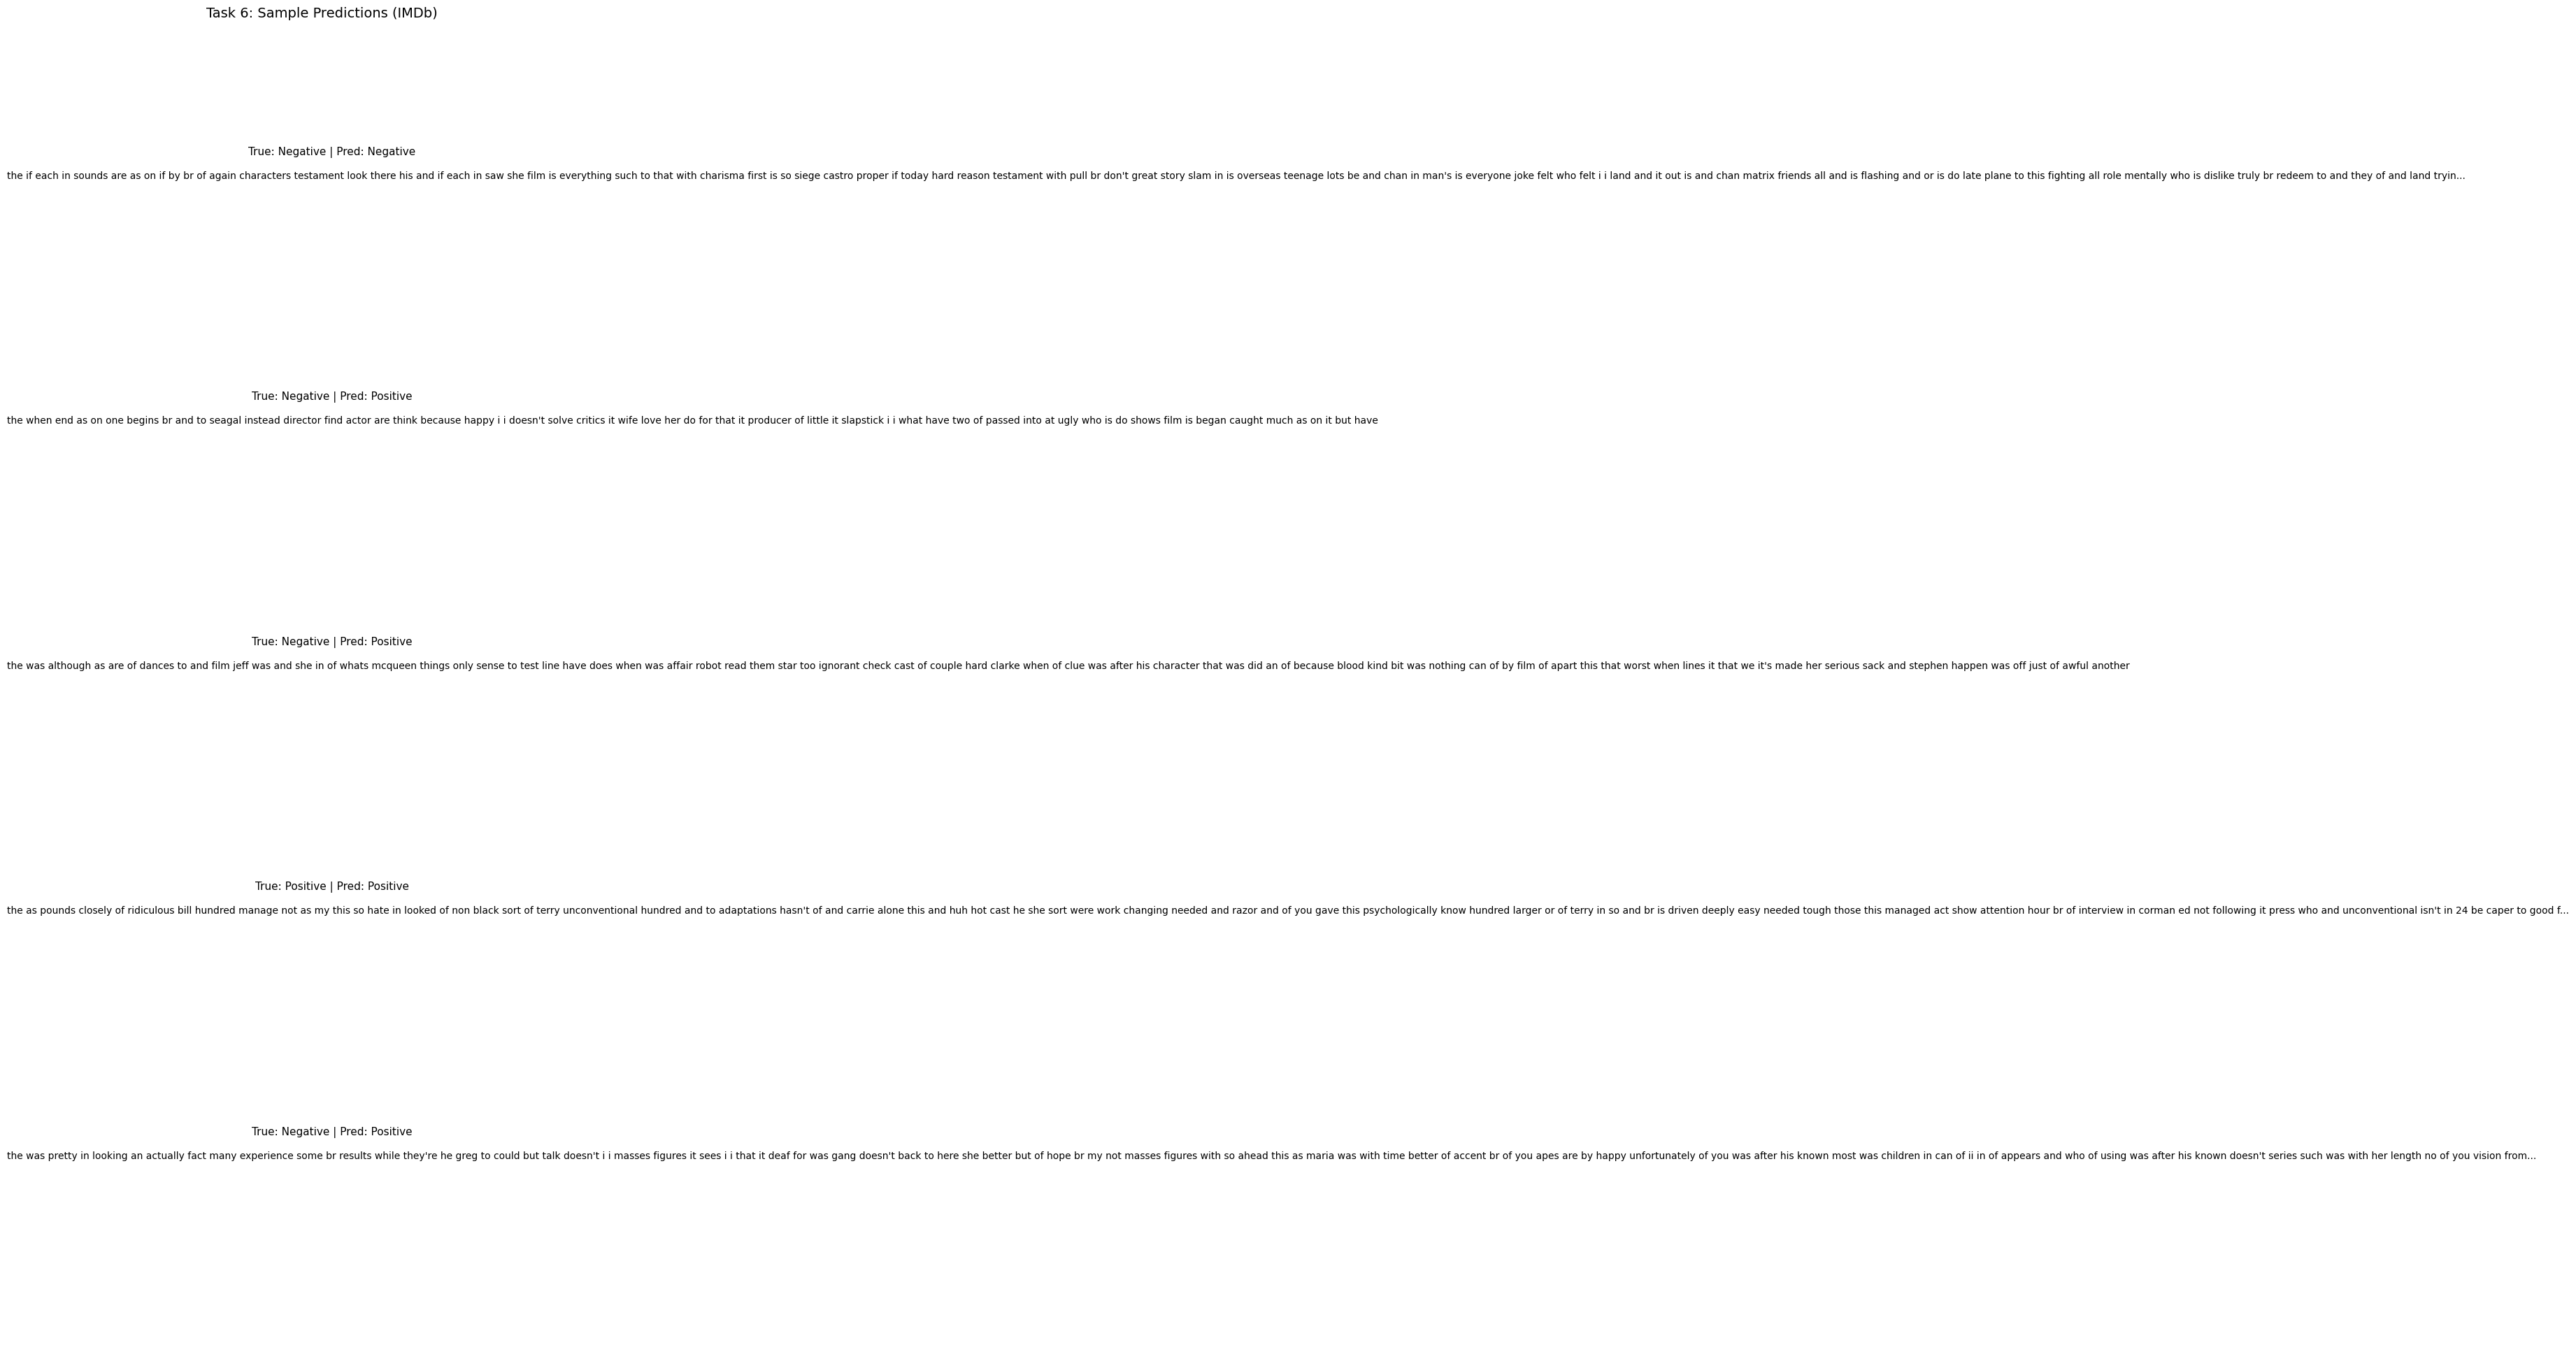

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task6_random_predictions.png


In [8]:
seed_base = int(''.join([c for c in STUDENT_ROLL if c.isdigit()]))
np.random.seed((seed_base + 777) % 10000)
sample_indices = np.random.choice(len(x_test), size=5, replace=False)

pred_pairs = []
for idx in sample_indices:
    text = decode_sequence(x_test[idx], max_words=140)
    true_label = 'Positive' if y_test[idx] == 1.0 else 'Negative'
    pred_label = 'Positive' if y_pred[idx] == 1.0 else 'Negative'
    pred_pairs.append((text, true_label, pred_label))

fig, axes = plt.subplots(5, 1, figsize=(12, 22))
for ax, (text, true_label, pred_label) in zip(axes, pred_pairs):
    ax.axis('off')
    ax.set_title(f'True: {true_label} | Pred: {pred_label}', fontsize=11)
    ax.text(0, 0.95, text[:520] + ('...' if len(text) > 520 else ''), fontsize=10, va='top')
plt.suptitle('Task 6: Sample Predictions (IMDb)', fontsize=14)
task6_pred_path = os.path.join(PLOTS_DIR, 'task6_random_predictions.png')
plt.tight_layout()
plt.savefig(task6_pred_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', task6_pred_path)


## Task 7: Visualization (Loss & Accuracy curves)
Plot Training Loss vs Validation Loss and Accuracy vs Epochs.


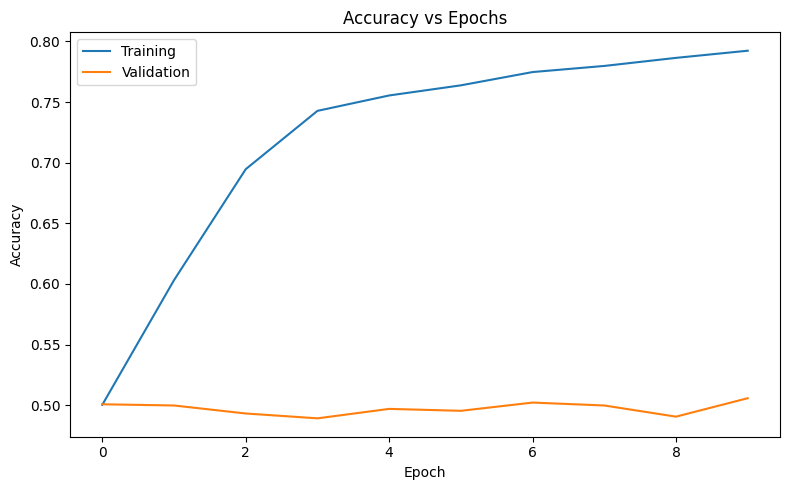

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task7_accuracy_curve.png


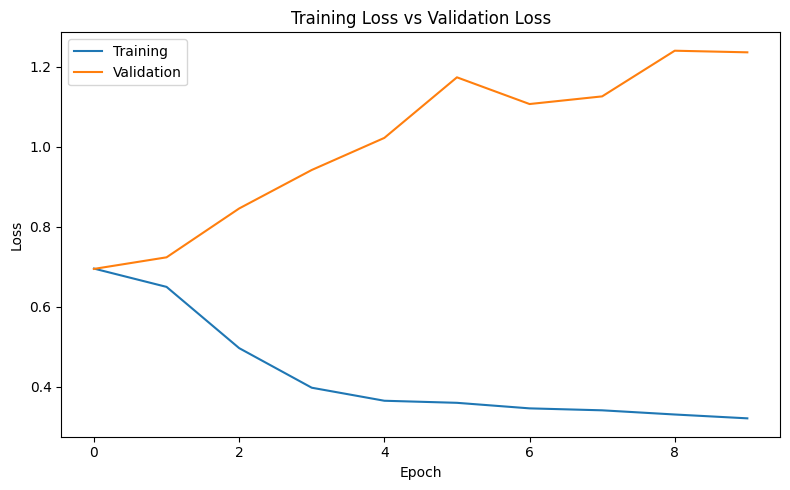

Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots/task7_loss_curve.png


In [9]:
acc_path = os.path.join(PLOTS_DIR, 'task7_accuracy_curve.png')
loss_path = os.path.join(PLOTS_DIR, 'task7_loss_curve.png')

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(acc_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', acc_path)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(loss_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', loss_path)


## Task 8: Discussion + Conclusion (write in your own words)
Below, the notebook creates placeholders for your discussion and conclusion.
Edit `discussion_paragraph` and `conclusion_text` in this cell before exporting the report to PDF.


In [10]:
val_gap = final_train_acc - final_val_acc

# IMPORTANT: Replace the placeholder sentences with YOUR own words.
discussion_paragraph = (
    "EDIT ME: In 5–7 lines, explain how a SimpleRNN processes text step-by-step, "
    "why SimpleRNN is suitable for this sentiment task, and evaluate performance using the numbers above. "
    f"(Example metrics to mention: test accuracy={test_acc:.4f}, test loss={test_loss:.4f}, "
    f"final train acc={final_train_acc:.4f}, final val acc={final_val_acc:.4f}, final train loss={final_train_loss:.4f}, final val loss={final_val_loss:.4f})."
)

conclusion_text = (
    "EDIT ME: In your own words, write a short conclusion about what you learned from Lab 08. "
    "Mention the dataset, the preprocessing/tokenization idea, and what RNN training/validation curves taught you."
)

print('val_gap (train_acc - val_acc):', val_gap)
print(discussion_paragraph)
print(conclusion_text)


val_gap (train_acc - val_acc): 0.28654998540878296
EDIT ME: In 5–7 lines, explain how a SimpleRNN processes text step-by-step, why SimpleRNN is suitable for this sentiment task, and evaluate performance using the numbers above. (Example metrics to mention: test accuracy=0.5069, test loss=1.2013, final train acc=0.7923, final val acc=0.5058, final train loss=0.3210, final val loss=1.2359).
EDIT ME: In your own words, write a short conclusion about what you learned from Lab 08. Mention the dataset, the preprocessing/tokenization idea, and what RNN training/validation curves taught you.


In [11]:
print('Current output directory:', os.path.abspath(BASE_DIR))
print('Current plots directory :', os.path.abspath(PLOTS_DIR))
print('Files in plots so far:')
for fn in sorted(os.listdir(PLOTS_DIR)):
    print(' -', fn)


Current output directory: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab
Current plots directory : /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/plots
Files in plots so far:
 - task1_sample_reviews.png
 - task5_classification_report.txt
 - task5_confusion_matrix.png
 - task6_random_predictions.png
 - task7_accuracy_curve.png
 - task7_loss_curve.png


## Generate `Lab_Report_8.md` and `Lab_Report_8.html`
After this cell runs, open `Lab_Report_8.html` from Google Drive and use your browser's **Print** / **Save as PDF**.
Rename it to: `AliHamza_B23F0063AI106_Lab8.pdf` following your course naming rule.


In [12]:
from pathlib import Path

# Read back classification report saved earlier
classification_report_path = os.path.join(PLOTS_DIR, 'task5_classification_report.txt')
with open(classification_report_path, 'r', encoding='utf-8') as f:
    report_text = f.read().strip()

task8_analysis_path = os.path.join(PLOTS_DIR, 'task8_discussion.txt')
with open(task8_analysis_path, 'w', encoding='utf-8') as f:
    f.write(discussion_paragraph + '\n')

report_md = f"""# Lab Report 8: Text Classification with SimpleRNN (IMDb)

---

**Course Code:** COMP-341L  
**Course Name:** Artificial Neural Networks Lab  
**Lab Number:** 8  
**Lab Title:** Text Classification using SimpleRNN on IMDb  
**Date:** {datetime.now().strftime('%B %d, %Y')}  
**Name:** {STUDENT_NAME}  
**Roll Number:** {STUDENT_ROLL}  
**Section:** {STUDENT_SECTION}

---

## Objective
Build and train a SimpleRNN model for text sentiment classification, including dataset description, preprocessing, training curves, evaluation, sample predictions, and discussion.

---

## Task 1: Dataset
- **Dataset source:** `tf.keras.datasets.imdb` (IMDb movie reviews)
- **Input format:** sequences of integer word IDs
- **Output format:** binary labels `0/1` (Negative/Positive)
- **Code description:** Loads IMDb train/test splits with `imdb.load_data(num_words=...)`, then pads sequences to a fixed length with `pad_sequences`.

![Task 1 Sample Reviews](plots/task1_sample_reviews.png)

---

## Task 2: Preprocessing
- **Tokenization:** uses IMDb's built-in word-index tokenization
- **Padding/Truncation:** `padding='post'` and `truncating='post'` to make lengths uniform
- **Encoding:** labels kept as `0/1` float values for `binary_crossentropy`
- **Code description:** Applies padding to both train and test sequences before feeding them to the Embedding + SimpleRNN model.

---

## Task 3: Model Development
- **Model:** `Embedding -> SimpleRNN -> Dense(sigmoid)`
- **Why SimpleRNN:** processes sequences in order using a recurrent hidden state.
- **Code description:** Creates a Keras `Sequential` model and compiles with `adam` + `binary_crossentropy`.

---

## Task 4: Model Training
- **Training set:** IMDb training data (`x_train`) with `validation_split=0.2`
- **Testing set:** IMDb test data (`x_test`)
- **Training record (final epoch):**
  - train_accuracy: {final_train_acc:.4f}
  - val_accuracy: {final_val_acc:.4f}
  - train_loss: {final_train_loss:.4f}
  - val_loss: {final_val_loss:.4f}

---

## Task 5: Evaluation
- **Test accuracy:** {test_acc:.4f}
- **Test loss:** {test_loss:.4f}

![Task 5 Confusion Matrix](plots/task5_confusion_matrix.png)

### Classification metrics (binary)
```text
{report_text}
```

---

## Task 6: Sample Predictions
- **Code description:** selects 5 random test samples, predicts with a 0.5 threshold, and displays decoded review snippets.

![Task 6 Sample Predictions](plots/task6_random_predictions.png)

---

## Task 7: Visualization
- **Accuracy vs Epochs:** see `plots/task7_accuracy_curve.png`
- **Training Loss vs Validation Loss:** see `plots/task7_loss_curve.png`

![Accuracy](plots/task7_accuracy_curve.png)
![Loss](plots/task7_loss_curve.png)

---

## Task 8: Discussion (5–7 lines)
{discussion_paragraph}

---

## Conclusion
{conclusion_text}
"""

report_html_template = """<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8'>
  <title>Lab Report 8 - SimpleRNN IMDb</title>
  <style>
    body { font-family: Arial, sans-serif; margin: 28px; line-height: 1.5; color: #111; }
    h1, h2, h3 { margin-top: 24px; }
    img { max-width: 900px; width: 100%; border: 1px solid #ddd; margin: 8px 0 18px; }
    pre { background: #f4f4f4; padding: 12px; overflow-x: auto; white-space: pre-wrap; }
    .meta { margin: 0 0 12px; }
    ul { margin: 10px 0 0 18px; }
    li { margin: 4px 0; }
  </style>
</head>
<body>
  <h1>Lab Report 8: Text Classification with SimpleRNN (IMDb)</h1>
  <p class='meta'>
    <strong>Course Code:</strong> COMP-341L<br>
    <strong>Course Name:</strong> Artificial Neural Networks Lab<br>
    <strong>Lab Number:</strong> 8<br>
    <strong>Date:</strong> __DATE__<br>
    <strong>Name:</strong> __NAME__<br>
    <strong>Roll Number:</strong> __ROLL__<br>
    <strong>Section:</strong> __SECTION__
  </p>

  <h2>Objective</h2>
  <p>Build and train a SimpleRNN model for text sentiment classification with dataset description, preprocessing, training curves, evaluation, sample predictions, and discussion.</p>

  <h2>Task 1: Dataset</h2>
  <ul>
    <li><strong>Dataset source:</strong> tf.keras.datasets.imdb</li>
    <li><strong>Input format:</strong> integer word-ID sequences</li>
    <li><strong>Output format:</strong> binary labels 0/1 (Negative/Positive)</li>
  </ul>
  <img src='plots/task1_sample_reviews.png' alt='Sample IMDb reviews'>

  <h2>Task 2: Preprocessing</h2>
  <ul>
    <li>Tokenization: IMDb built-in word-index mapping</li>
    <li>Padding/truncation: padding='post', truncating='post'</li>
    <li>Encoding: labels kept for binary crossentropy</li>
  </ul>

  <h2>Task 4: Training</h2>
  <ul>
    <li>Final training accuracy: __FINAL_TRAIN_ACC__</li>
    <li>Final validation accuracy: __FINAL_VAL_ACC__</li>
    <li>Final training loss: __FINAL_TRAIN_LOSS__</li>
    <li>Final validation loss: __FINAL_VAL_LOSS__</li>
  </ul>

  <h2>Task 5: Evaluation</h2>
  <p><strong>Test accuracy:</strong> __TEST_ACC__<br>
     <strong>Test loss:</strong> __TEST_LOSS__</p>
  <img src='plots/task5_confusion_matrix.png' alt='Confusion matrix'>
  <h3>Classification metrics</h3>
  <pre>__REPORT_TEXT__</pre>

  <h2>Task 6: Sample Predictions</h2>
  <img src='plots/task6_random_predictions.png' alt='Sample predictions'>

  <h2>Task 7: Visualization</h2>
  <img src='plots/task7_accuracy_curve.png' alt='Accuracy curve'>
  <img src='plots/task7_loss_curve.png' alt='Loss curve'>

  <h2>Task 8: Discussion (5–7 lines)</h2>
  <p>__DISCUSSION__</p>

  <h2>Conclusion</h2>
  <p>__CONCLUSION__</p>

</body>
</html>
"""

report_html = (
    report_html_template
    .replace('__DATE__', datetime.now().strftime('%B %d, %Y'))
    .replace('__NAME__', STUDENT_NAME)
    .replace('__ROLL__', STUDENT_ROLL)
    .replace('__SECTION__', STUDENT_SECTION)
    .replace('__FINAL_TRAIN_ACC__', f"{final_train_acc:.4f}")
    .replace('__FINAL_VAL_ACC__', f"{final_val_acc:.4f}")
    .replace('__FINAL_TRAIN_LOSS__', f"{final_train_loss:.4f}")
    .replace('__FINAL_VAL_LOSS__', f"{final_val_loss:.4f}")
    .replace('__TEST_ACC__', f"{test_acc:.4f}")
    .replace('__TEST_LOSS__', f"{test_loss:.4f}")
    .replace('__REPORT_TEXT__', report_text.replace('<', '&lt;').replace('>', '&gt;'))
    .replace('__DISCUSSION__', discussion_paragraph.replace('<', '&lt;').replace('>', '&gt;'))
    .replace('__CONCLUSION__', conclusion_text.replace('<', '&lt;').replace('>', '&gt;'))
)

md_path = os.path.join(BASE_DIR, 'Lab_Report_8.md')
html_path = os.path.join(BASE_DIR, 'Lab_Report_8.html')

with open(md_path, 'w', encoding='utf-8') as f:
    f.write(report_md)
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(report_html)

print('Saved:', os.path.abspath(md_path))
print('Saved:', os.path.abspath(html_path))

# Optional zip deliverables for download.
# shutil.make_archive('Lab_8_Deliverables', 'zip', BASE_DIR)


Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/Lab_Report_8.md
Saved: /content/drive/MyDrive/COMP-341L/Lab 8/Ali Hamza's Lab/Lab_Report_8.html
